# 02 · `asb.Opti` in depth: how every problem in this repository is posed and solved

`asb.Opti` is AeroSandbox's thin layer over CasADi's `Opti` stack, which hands the NLP to IPOPT. Every solve in the
repository, from the 2-variable examples to the Halo sizing, is one `asb.Opti` object filled in the same way:

```python
opti = asb.Opti()
x = opti.variable(init_guess=..., scale=..., lower_bound=..., upper_bound=...)   # design / state variables
opti.subject_to(residual == 0)                                                   # equalities
opti.subject_to(margin >= 0)                                                     # inequalities
opti.minimize(objective)
solution = opti.solve(verbose=False, max_iter=...)
value = solution.value(any_expression)                                           # post-processing
```

This notebook goes through each call with the details that matter for reading and writing this code: how scaling is
applied (and inferred when you do not give it), that bounds become constraint rows, what `subject_to` returns, how to read
IPOPT's log, how failures surface, and how the code warm-starts.

**In this notebook**
1. A small aircraft problem, posed and solved.
2. `variable(...)`: initial guess, scale (and the inferred default), bounds, `freeze`, `log_transform`.
3. `subject_to(...)`: equalities, inequalities, vectors, and the dual variables it returns.
4. `solve(...)`: reading the IPOPT log; `stats()`; options.
5. `solution.value(...)`: evaluating anything at the optimum.
6. Failure: infeasibility, iteration limits, `behavior_on_failure`, and debugging.
7. Parameters, sweeps and warm starts.

**Run time:** a few seconds.

In [1]:
from tutorial_helpers import *
import numpy as onp

## 1. A small aircraft problem

Choose the wing area $S$ and flight speed $V$ of a propeller aircraft to **minimize the power for level flight**.
The wing has a mass per unit area, so a bigger wing is heavier. Lift must equal weight, the lift coefficient must stay
below a usable maximum, and the stall speed must be at most 20 m/s.

$$P = D\,V,\qquad D = q S \Big(C_{D0} + \frac{C_L^2}{\pi e A}\Big),\qquad C_L = \frac{W}{qS},\qquad W = (m_0 + w_S S)\,g$$

In [2]:
g = 9.80665
density_kg_m3 = asb.Atmosphere(altitude=1000.0).density()
mass_fixed_kg, mass_per_area_kg_m2 = 900.0, 12.0
cd0, oswald, aspect_ratio, cl_max = 0.025, 0.8, 9.0, 1.4

def level_flight(area_wing_m2, velocity_m_s):
    """Everything about the flight condition, as expressions (numbers or symbols)."""
    weight_N = (mass_fixed_kg + mass_per_area_kg_m2 * area_wing_m2) * g
    dynamic_pressure_Pa = 0.5 * density_kg_m3 * velocity_m_s**2
    cl = weight_N / (dynamic_pressure_Pa * area_wing_m2)
    drag_N = dynamic_pressure_Pa * area_wing_m2 * (cd0 + cl**2 / (np.pi * oswald * aspect_ratio))
    velocity_stall_m_s = np.sqrt(2 * weight_N / (density_kg_m3 * area_wing_m2 * cl_max))
    return dict(weight_N=weight_N, cl=cl, drag_N=drag_N, power_W=drag_N * velocity_m_s,
                velocity_stall_m_s=velocity_stall_m_s)

opti = asb.Opti()
area_wing_m2 = opti.variable(init_guess=15.0, scale=10.0, lower_bound=1.0)
velocity_m_s = opti.variable(init_guess=40.0, scale=10.0, lower_bound=10.0)
flight = level_flight(area_wing_m2, velocity_m_s)
dual_stall = opti.subject_to(flight["velocity_stall_m_s"] / 20.0 <= 1)        # normalized: a ratio of order one
dual_cl = opti.subject_to(flight["cl"] / cl_max <= 1)
opti.minimize(flight["power_W"] / 1e4)                                          # objective of order one
solution = opti.solve(verbose=False)

print(f"S = {solution.value(area_wing_m2):.2f} m2, V = {solution.value(velocity_m_s):.2f} m/s, "
      f"P = {solution.value(flight['power_W']) / 1e3:.2f} kW, CL = {solution.value(flight['cl']):.3f}, "
      f"V_stall = {solution.value(flight['velocity_stall_m_s']):.2f} m/s")
print(f"IPOPT: {solution.stats()['iter_count']} iterations, status {solution.stats()['return_status']}")

S = 45.65 m2, V = 20.74 m/s, P = 22.60 kW, CL = 1.302, V_stall = 20.00 m/s
IPOPT: 8 iterations, status Solve_Succeeded


Verify by brute force on a grid (the kind of check every tutorial uses to make sure the solver is not fooling us):

grid optimum: S = 45.70 m2, V = 20.70 m/s, P = 22.60 kW
PASS  IPOPT's optimum is no worse than the best grid point


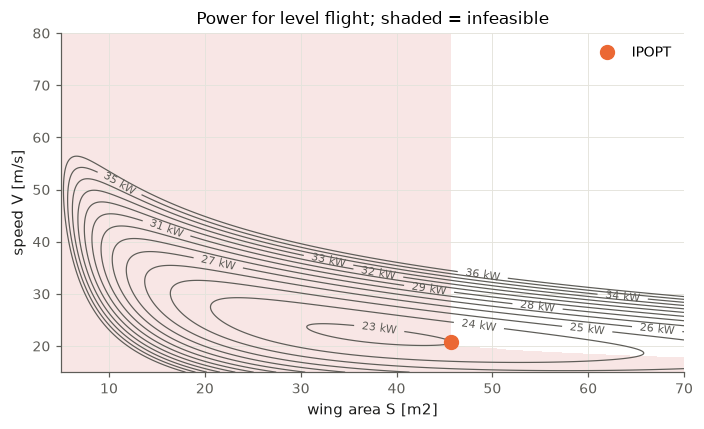

In [3]:
areas = onp.linspace(5, 70, 651)
speeds = onp.linspace(15, 80, 651)
A, V = onp.meshgrid(areas, speeds)
grid = level_flight(A, V)
feasible = (grid["velocity_stall_m_s"] <= 20.0) & (grid["cl"] <= cl_max)
power_grid_W = onp.where(feasible, grid["power_W"], onp.inf)
k = onp.unravel_index(onp.argmin(power_grid_W), power_grid_W.shape)
print(f"grid optimum: S = {A[k]:.2f} m2, V = {V[k]:.2f} m/s, P = {power_grid_W[k] / 1e3:.2f} kW")
check("IPOPT's optimum is no worse than the best grid point",
      solution.value(flight["power_W"]) <= power_grid_W[k] + 1.0)

fig, ax = plt.subplots(figsize=(6.5, 4))
levels = onp.linspace(power_grid_W[k] / 1e3, power_grid_W[k] / 1e3 * 1.6, 13)
cs = ax.contour(A, V, grid["power_W"] / 1e3, levels=levels, colors=ink_muted, linewidths=0.8)
ax.clabel(cs, fmt="%.0f kW", fontsize=7)
ax.contourf(A, V, ~feasible, levels=[0.5, 1.5], colors=[red], alpha=0.12)
ax.plot(solution.value(area_wing_m2), solution.value(velocity_m_s), "o", color=orange, ms=9, label="IPOPT")
ax.set(xlabel="wing area S [m2]", ylabel="speed V [m/s]", title="Power for level flight; shaded = infeasible")
ax.legend(); plt.tight_layout(); plt.show()

The optimum sits on the stall-speed boundary: the stall constraint is **active**. We will read its multiplier in
section 3.

## 2. `opti.variable(...)`

### Scaling: `variable = scale × (the variable IPOPT sees)`

AeroSandbox creates a raw CasADi decision variable $\hat x$ and returns the *expression* $x = s\,\hat x$. IPOPT iterates
on $\hat x$, which is of order one if the scale is the right order of magnitude. That is why you saw `(20*opti0_x_1)` in
tutorial 01.

**If you omit `scale`, AeroSandbox infers it from the initial guess:** $s = |x_0|$ (or 1 if $x_0 = 0$). So a good initial
guess also gives a good scale, and a zero initial guess gives scale 1 regardless of the variable's real magnitude. The
Halo driver therefore gives explicit scales for anything whose start could be zero or far from its value
(battery energy `scale=1e8`, take-off mass `scale=1000`, rotor speed `scale=100`). Let us confirm the inference:

In [4]:
probe = asb.Opti()
for init_guess, scale in ((2.5e7, None), (0.0, None), (2.5e7, 1e8), (-40.0, None)):
    x = probe.variable(init_guess=init_guess, scale=scale)
    print(f"init_guess {init_guess:>9g}, scale given {str(scale):>6}  ->  expression {x}")

init_guess   2.5e+07, scale given   None  ->  expression (25000000*opti1_x_1)
init_guess         0, scale given   None  ->  expression opti1_x_2
init_guess   2.5e+07, scale given 100000000.0  ->  expression (100000000*opti1_x_3)
init_guess       -40, scale given   None  ->  expression (40*opti1_x_4)


### Bounds are constraint rows, written in scaled form

`lower_bound=` and `upper_bound=` do not use IPOPT's native variable bounds. AeroSandbox adds them as ordinary
constraints $x/s \ge \text{lb}/s$. They are still handled well by IPOPT (they are linear), but they count in the
constraint total, and an active bound has a multiplier like any other constraint. `describe_opti` (from the helpers)
counts the rows of the problem above:

In [5]:
print(describe_opti(opti))
check("2 variables; 2 bound rows + 2 named inequalities = 4 constraint rows", describe_opti(opti)["constraints"] == 4)

{'variables': 2, 'constraints': 4, 'equalities': 0, 'inequalities': 4}
PASS  2 variables; 2 bound rows + 2 named inequalities = 4 constraint rows


### `freeze` and `log_transform`

- `freeze=True` returns the initial guess as a constant instead of a variable. The code doesn't use it: it fixes a
  quantity by passing a number where a variable would go (every component field is typed `Any` for this reason, see
  tutorial 04). The effect is the same.
- `log_transform=True` optimizes $\ln x$ (positive variables spanning decades). The code doesn't use it either; it relies
  on scales.

## 3. `opti.subject_to(...)` and dual variables

`subject_to` accepts a CasADi comparison (`==`, `<=`, `>=`), a list of them, or a vector comparison, and **returns the dual
variable(s)**. After the solve, `solution.value(dual)` is the Lagrange multiplier.

The sign convention, empirically: for a constraint written `g(x) <= 1` (or `>= 0`), the returned multiplier is
non-negative when the constraint is active, and it measures how much the **objective** (in its own scaled units) would
*improve* per unit relaxation of the constraint expression as written. Check it on the stall constraint by
re-solving with a stall limit of 20.02 m/s, a relaxation of 0.001 in `V_stall / 20 <= 1`:

In [6]:
def solve_wing(velocity_stall_max_m_s):
    o = asb.Opti()
    S = o.variable(init_guess=15.0, scale=10.0, lower_bound=1.0)
    V = o.variable(init_guess=40.0, scale=10.0, lower_bound=10.0)
    f = level_flight(S, V)
    o.subject_to(f["velocity_stall_m_s"] / velocity_stall_max_m_s <= 1)
    o.subject_to(f["cl"] / cl_max <= 1)
    o.minimize(f["power_W"] / 1e4)
    return o.solve(verbose=False).value(f["power_W"] / 1e4)

lam_stall = solution.value(dual_stall)
lam_cl = solution.value(dual_cl)
print(f"multiplier of the stall constraint: {lam_stall:.4f}   (CL constraint: {lam_cl:.2e}, inactive)")
objective_base, objective_relaxed = solve_wing(20.0), solve_wing(20.02)
# V_stall/20.02 <= 1 is V_stall/20 <= 1.001: the right-hand side relaxed by 0.001
print(f"predicted objective change  -lambda x 0.001 = {-lam_stall * 0.001:+.6f}")
print(f"re-solved objective change                = {objective_relaxed - objective_base:+.6f}")
check("the multiplier predicts the re-solved improvement to first order",
      abs(-lam_stall * 0.001 - (objective_relaxed - objective_base)) < 0.05 * abs(objective_relaxed - objective_base))
check("an inactive constraint has a (near) zero multiplier", abs(lam_cl) < 1e-6)

multiplier of the stall constraint: 0.4911   (CL constraint: 1.56e-10, inactive)
predicted objective change  -lambda x 0.001 = -0.000491
re-solved objective change                = -0.000486
PASS  the multiplier predicts the re-solved improvement to first order
PASS  an inactive constraint has a (near) zero multiplier


Two things make multipliers readable in this code base:

1. **Objectives are scaled to order one**, usually `mass_takeoff_kg / 1000` (tonnes).
2. **Every limit is a normalized margin** ($(\text{limit} - \text{value}) / \text{limit} \ge 0$, tutorial 04), so one unit of
   margin is "100 % of the limit" for every constraint.

So a multiplier of 1.2 on a margin means *relaxing that limit by 1 % saves about 12 kg of take-off mass*. Tutorial 03
uses this on a sizing toy, and the deep dives read the multipliers of the Halo solve.

## 4. `opti.solve(...)` and the IPOPT log

The code always calls `solve(verbose=False)` except when debugging. Here is the log of the problem above with
`verbose=True`, so you can read one:

In [7]:
o = asb.Opti()
S = o.variable(init_guess=15.0, scale=10.0, lower_bound=1.0)
V = o.variable(init_guess=40.0, scale=10.0, lower_bound=10.0)
f = level_flight(S, V)
o.subject_to([f["velocity_stall_m_s"] / 20.0 <= 1, f["cl"] / cl_max <= 1])
o.minimize(f["power_W"] / 1e4)
verbose_solution = o.solve(verbose=True)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        5
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        4
        inequality constraints with only lower bounds:        2
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        2

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.8211163e+00 5.07e-01 6.51e-01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

How to read it:

| Column | Meaning | What to look for |
|---|---|---|
| `iter` | iteration (`r` suffix: restoration phase) | a run of `r` means IPOPT lost feasibility and is trying to recover |
| `objective` | the scaled objective | |
| `inf_pr` | primal infeasibility (largest constraint violation) | must go to ~1e-8 or below |
| `inf_du` | dual infeasibility (KKT stationarity) | must go to ~1e-8 or below |
| `lg(mu)` | log10 of the barrier parameter | falls as the interior point converges |
| `alpha_pr` | step length | many tiny steps: a kink, bad scaling or a bad start |

The header also reports the problem size: number of variables, of equality and inequality constraints, and nonzeros in
the Jacobian and Hessian. On the full Halo problem you will see a few hundred variables and around a thousand constraints.

`solution.stats()` returns the same information as a dictionary:

In [8]:
stats = verbose_solution.stats()
print({key: stats[key] for key in ("return_status", "iter_count", "success")})

{'return_status': 'Solve_Succeeded', 'iter_count': 8, 'success': True}


Options the code uses: `max_iter` (the Halo driver passes up to 3,000) and occasionally `options={"ipopt.mu_strategy": ...}`.
Everything else is IPOPT's default.

## 5. `solution.value(...)`: post-processing

`solution.value` evaluates **any** expression built on the problem's variables, including ones never constrained or
minimized. This is how every result dataclass in the repository is filled: the driver keeps the expression objects
(masses, powers, margins) and converts them with `value` at the end, the *only* place where `float()` appears.

In [9]:
print(f"weight            {solution.value(flight['weight_N']) / g:,.1f} kg")
print(f"drag              {solution.value(flight['drag_N']):,.1f} N")
print(f"L/D               {solution.value(flight['weight_N'] / flight['drag_N']):.2f}")
print(f"stall margin      {solution.value(1 - flight['velocity_stall_m_s'] / 20.0):.2e}")

weight            1,447.8 kg
drag              1,090.1 N
L/D               13.02
stall margin      -9.98e-09


## 6. When it fails

### An infeasible problem

Ask for a stall speed of 15 m/s with this wing loading and CL limit. No wing mass small enough exists, so the problem is
infeasible. IPOPT says so, and `asb.Opti.solve` raises a `RuntimeError` carrying the status:

In [10]:
o = asb.Opti()
S = o.variable(init_guess=15.0, scale=10.0, lower_bound=1.0, upper_bound=40.0)
V = o.variable(init_guess=40.0, scale=10.0, lower_bound=10.0)
f = level_flight(S, V)
o.subject_to([f["velocity_stall_m_s"] / 15.0 <= 1, f["cl"] / cl_max <= 1])
o.minimize(f["power_W"] / 1e4)
try:
    o.solve(verbose=False)
except RuntimeError as error:
    message = str(error)
    print("RuntimeError:", message[message.find("return_status"):][:80] if "return_status" in message else message[:200])

RuntimeError: return_status is 'Infeasible_Problem_Detected'


### Looking at the failed iterate

`opti.debug.value(expr)` evaluates expressions at the last iterate after a failure, which tells you *which* constraint
could not be met. Alternatively `solve(behavior_on_failure="return_last")` returns that iterate as a solution object
instead of raising:

In [11]:
last = o.solve(verbose=False, behavior_on_failure="return_last")
print(f"last iterate: S = {last.value(S):.2f} m2 (upper bound 40), V_stall = {last.value(f['velocity_stall_m_s']):.2f} m/s "
      f"(asked <= 15)")
check("the failed iterate shows the wing at its upper bound, still too fast at stall",
      last.value(S) > 39.0 and last.value(f["velocity_stall_m_s"]) > 15.0)

last iterate: S = 40.00 m2 (upper bound 40), V_stall = 20.86 m/s (asked <= 15)
PASS  the failed iterate shows the wing at its upper bound, still too fast at stall


C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\aerosandbox\optimization\opti.py:920: UserWarning: Optimization failed. Returning last solution.
  warnings.warn("Optimization failed. Returning last solution.")


The Halo driver treats `RuntimeError` from a solve as "this starting point failed" and tries the next start in an explicit
list (tutorial 20). It never retries in a loop on the same problem.

Common failure causes, roughly in the order they occur in this code base:

1. **A bad initial guess** (a variable far from its optimum, or at a point where some expression is undefined, such as a
   negative argument under a square root). Fix: a better guess, or a simpler precursor problem solved first.
2. **Poor scaling** (a variable or residual of order 1e5 next to one of order 1e-3). Fix: `scale=`, normalized
   constraints.
3. **A kink** (`max`, `abs`, piecewise tables). Fix: smooth replacements.
4. **Genuine infeasibility** (requirements no aircraft can meet). Fix: the requirements, or a model.

## 7. Parameters, sweeps and warm starts

`opti.parameter(value)` creates a symbol that is fixed during a solve but can be changed between solves without rebuilding
the problem; `opti.solve_sweep({parameter: values})` loops over values. The repository's drivers instead rebuild the
problem from dataclasses each time (cheap compared with the solve, and simpler to read), and warm-start by passing an
earlier result as `initial=` so every variable's `init_guess` comes from it. Both patterns, on the wing problem:

In [12]:
o = asb.Opti()
velocity_stall_max = o.parameter(20.0)
S = o.variable(init_guess=15.0, scale=10.0, lower_bound=1.0)
V = o.variable(init_guess=40.0, scale=10.0, lower_bound=10.0)
f = level_flight(S, V)
o.subject_to([f["velocity_stall_m_s"] / velocity_stall_max <= 1, f["cl"] / cl_max <= 1])
o.minimize(f["power_W"] / 1e4)
limits = onp.array([17.0, 18.5, 20.0, 21.5, 23.0])
powers_kW = []
for limit in limits:
    o.set_value(velocity_stall_max, limit)
    powers_kW.append(o.solve(verbose=False).value(f["power_W"]) / 1e3)
for limit, power in zip(limits, powers_kW):
    print(f"stall limit {limit:4.1f} m/s -> minimum power {power:6.2f} kW")
check("a stricter stall limit never needs less power", onp.all(onp.diff(powers_kW) <= 1e-6))

# Warm start (the code's `initial=` pattern): use the previous optimum as the initial guess of a new problem.
previous = dict(S=solution.value(area_wing_m2), V=solution.value(velocity_m_s))
o2 = asb.Opti()
S2 = o2.variable(init_guess=previous["S"], scale=10.0, lower_bound=1.0)
V2 = o2.variable(init_guess=previous["V"], scale=10.0, lower_bound=10.0)
f2 = level_flight(S2, V2)
o2.subject_to([f2["velocity_stall_m_s"] / 20.5 <= 1, f2["cl"] / cl_max <= 1])
o2.minimize(f2["power_W"] / 1e4)
warm = o2.solve(verbose=False)
print(f"\nwarm-started re-solve with a 20.5 m/s limit: {warm.stats()['iter_count']} iterations "
      f"(cold start above: {solution.stats()['iter_count']})")

stall limit 17.0 m/s -> minimum power  25.07 kW
stall limit 18.5 m/s -> minimum power  23.30 kW
stall limit 20.0 m/s -> minimum power  22.60 kW
stall limit 21.5 m/s -> minimum power  22.45 kW
stall limit 23.0 m/s -> minimum power  22.45 kW
PASS  a stricter stall limit never needs less power

warm-started re-solve with a 20.5 m/s limit: 7 iterations (cold start above: 8)


## Summary

- `variable` returns `scale × raw`; the scale defaults to `|init_guess|` (1 if the guess is 0), so give explicit scales.
- Bounds are linear constraint rows, with multipliers like any other constraint.
- `subject_to` returns duals; with order-one objectives and normalized margins, multipliers read as "objective units per
  100 % of the limit".
- Read IPOPT's `inf_pr` and `inf_du` columns; restoration (`r`) and tiny steps signal trouble.
- `solution.value` evaluates any expression at the optimum; that is the only place numbers leave the graph.
- Failures raise `RuntimeError`; inspect the last iterate with `behavior_on_failure="return_last"` or `opti.debug`.

## Check yourself

<details><summary>1. You declare <code>current_battery_A = opti.variable(init_guess=0.0)</code>. What scale does IPOPT see, and why could it matter?</summary>

Scale 1 (inferred from a zero guess). If the current ends up in the hundreds of amperes, IPOPT works on a raw variable of order 100, next to others of order one, which can slow convergence. The flight point gives `scale=100.0` explicitly for this reason (`performance/flight_point.py`).
</details>

<details><summary>2. A margin has multiplier 0.0 at the optimum, another has 0.8. Which one sizes the design?</summary>

The second: it is active and relaxing it would reduce the objective (by about 0.8 objective units per unit of margin). The first is inactive (or weakly active); relaxing it changes nothing to first order.
</details>

<details><summary>3. Why does the code rebuild the Opti problem for each study instead of using parameters?</summary>

Clarity: each study is a plain function of dataclasses (requirements, assumptions) and reads top to bottom, and many studies change the *structure* (a different battery model, more flight points), which a parameter cannot do. Building the graph is cheap compared with solving it.
</details>

In [13]:
check_summary()

6 of 6 checks passed
